In [1]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Samuele Taviano
# Matricole: 660185, ?

In [2]:
import numpy as np
import optuna
from sklearn.preprocessing import StandardScaler
import cup_common as cc
import nn_common as nnc
import cross_common as cr
import torch
import importlib
from functools import partial
import copy
from nn_common import FeatureTargetSet, HoldOutStrategy, EarlyStoppingStrategy
from cross_common import EPOCHS_VL_LOSS,FOLD_VL_LOSS,FOLD_TR_LOSS
from cross_common import MEE,MSE,RMSE,MAE,LOSS


importlib.reload(nnc)
importlib.reload(cc)
importlib.reload(cr)

/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'cross_common' from '/Users/leonardo/workspace/library/source/it.unipi.654AA/notebooks/cross_common.py'>

<h1>NN - Optuna</h1>
<h2>Exploring the cup dataset with NN Classifier with the help of Optuna tools.</h2>
<p>This notebook serves the purpose of exploring the hypotesis space by manually varying the hyperparameters and for inspecting the whole pipeline.</p>
<hr/>

<h3>Preparation</h3>
<hr/>

<h4>Data preparation</h4>
<p>The train and test dataset are loaded in form of Pandas DataFrame for better interaction with PyTorch.
Eventually there will be these objects:
<ul>
<li>X_tr, y_tr: the train features and train labels (or classes)</li>
<li>X_ts, y_ts: the test features and test labels (or classes)</li>
</ul>
</p>

In [3]:
importlib.reload(cr)
df_train, df_test = cc.load_set()

# Scaler
scaler = StandardScaler()
# The train set used for model selection
# and final testing
X_tr, y_tr = cc.prepare_dataset(df_train)
X_ts, y_ts = cc.prepare_dataset(df_test)


features_names = X_tr.columns
cr.dataset_introspection(X_tr, X_ts)

,Property,Training,Test
0,Number of samples,500,1000
1,Number of features,10,10
2,Class values,[],[]
3,Class balance,[],[]


<h4>Network Architecture</h4>
<p>Defining and selecting a hypothesis space with hyper-parameter around a neural network architecture:
<ul>
<li><b>net</b>: represent the internal NN structure with input, hidden and output layer.
One important thing to consider is that the output layer <u>must be kept linear</u> in order to be able to
plug the loss function and the output adapter</li>
<li><b>output_adapter</b>: the function which takes the output from the NN and apply the latest trasformation (classification, regression, etc...).
Must be coherent with the optimizer_template. See function docs for details</li>
<li><b>model_template</b>: the model itself, a skeleton which holds the net structure, and the output adapter function.
The model is always cloned troughout the notebok, just to keep a template reference.</li>
<li><b>optimizer_template</b>: the weight update algorithm</li>
<li><b>scheduler_template</b>: implements adaptive learning rate decay by using ReduceLROnPlateau together with the optimizer template</li>
</ul>
</p>

In [4]:
# Set to True when model is selcted and assessed
dump_prediction = False

# The seed to be used by data splitter
default_state = 42
default_seed = 1

default_batch_size = [64]
default_epochs = 1000

# The input dimension (i.e. the input layer) is obviously
# the number of feature of the TR set
input_dimension = X_tr.shape[1]
output_dimension = 4

# fold strategy
base_fold_strategy = cr.common_fold_strategy(n_split=3)


# ---- The metrics to calculate in train ---
epochs_metrics_dict = {
    LOSS: (nnc.MEELoss, min),
    MSE: (cr.mse,min),
    MAE: (cr.mae,min),
    RMSE: (cr.rmse,min),
}
the_metrics = epochs_metrics_dict.keys()
# ------------------------------------------


# ----- Defining model basic architecture --------
base_hidden_layers = ["32"]

# The output and loss function, must be changed according to the type of task
loss_function = nnc.MEELoss()
# activation function
base_activation_function = ["relu"]
output_adapter = nnc.regression_adapter()
# ------------------------------------------


# ------------ Learning rate ---------------
base_weight_decay = [0]
# ------------------------------------------


# --------- Early Stopping Strategy --------
early_stopping_patience = 50 # how many epochs to wait before stopping
early_stopping_min_delta = 1e-2 #1e-4 # the treshold or delta to declare an epochs as not improved
early_stopping_strategy = EarlyStoppingStrategy(patience=early_stopping_patience, min_delta=early_stopping_min_delta)
# ------------------------------------------


# ---------- Learning rate decay -----------
# The factor by which learning rate will decrease
learning_rate_decay_factor = 0.5    #0.6 #0.5
# The epoch to wait before applying the rate decay factor (must be lower than early stopping)
learning_rate_decay_patience = 10
# The threshold for measuring the new optimum
learning_rate_decay_threshold = 1e-2 #1e-4

# The learning rate decay function
scheduler_template = partial(
    torch.optim.lr_scheduler.ReduceLROnPlateau,
    mode="min", factor=learning_rate_decay_factor, patience=learning_rate_decay_patience,
    threshold=learning_rate_decay_threshold
)
# ------------------------------------------


In [5]:
def objective(trial, X, y, trial_dict, objective_function):
    """
    Main objective function to be used with Optuna search.
    :param trial: the optuna trial object
    :param X: the feature
    :param y: the target
    :param trial_dict: the configuration dictionary
    :param objective_function: the objective function
    :return:
    """

    epochs_trial = trial_dict["epochs"]
    batch_size_trial = nnc.suggest_trial_param(trial, "batch_size", trial_dict["batch_size"])
    fold_strategy_trial = trial_dict["fold_strategy"]
    output_adapter_trial = trial_dict["output_adapter"]
    scheduler_template_trial = trial_dict.get("scheduler_template",None)
    hidden_layers_raw = nnc.suggest_trial_param(trial, "hidden_layers", trial_dict["hidden_layers"])
    hidden_layers_trial = [int(x) for x in hidden_layers_raw.split(",")]
    activation_trial = nnc.suggest_trial_param(trial,"activation", trial_dict["activation"])
    learning_rate_trial = nnc.suggest_trial_param(trial, "learning_rate", trial_dict["learning_rate"])
    weight_decay_trial = nnc.suggest_trial_param(trial, "weight_decay", trial_dict["weight_decay"])
    metrics_trial = trial_dict["metrics"]
    net_trial = nnc.build_nn_net(input_dimension, output_dimension, list(hidden_layers_trial), activation_trial)
    model_trial = nnc.build_nn_model(net_trial, output_adapter_trial)

    optimizer_template_trial = partial(
        torch.optim.AdamW,
        lr=learning_rate_trial,
        weight_decay=weight_decay_trial,
        betas=(0.95, 0.999)
    )

    inner_train_params_trial = {
        "epochs": epochs_trial,
        "batch_size": batch_size_trial,
        "scheduler_template": scheduler_template_trial,
        "optimizer_template": optimizer_template_trial,
        "loss_function": loss_function,
        "early_stopping_strategy": early_stopping_strategy,
        "silence_output": True,
        "metrics": metrics_trial
    }

    return objective_function(
        nnc.kfold(model_trial, X, y, fold_strategy_trial, inner_train_params_trial, scaler)
    )


<h3>Optuna</h3>

<h4>Learning Rate</h4>
<hr>

<h5>Preparation</h5>

In [6]:

# partially instantiate evaluation funtion
evaluate_lr_partial = partial(
    nnc.evaluate_lr,
    epoch_metric=EPOCHS_VL_LOSS,
    fold_metric=FOLD_VL_LOSS,
    early_epoch=30
)

coarse_learning_rates = [1e-4, 5e-4, 1e-3, 2e-3, 3e-3]

<h5>Coarse Grained</h5>

In [7]:
# as we are testing few lr a small
# nr of trials is enough
coarse_grained_trials_nr = 20

objective_coarse_grained_lr_partial = partial(
    objective,X=X_tr,y=y_tr,objective_function = evaluate_lr_partial,
    trial_dict={
        "epochs": 100, # we use a small epochs nr
        "batch_size": default_batch_size,
        "fold_strategy": base_fold_strategy,
        "input_dimension":input_dimension,
        "output_dimension":output_dimension,
        "hidden_layers": base_hidden_layers,
        "learning_rate": coarse_learning_rates,
        "weight_decay": base_weight_decay,
        "activation": base_activation_function,
        "output_adapter": output_adapter,
        "metrics": epochs_metrics_dict,
    }
)

coarse_grained_lr_study = optuna.create_study(
    # see find_best_lr_from_trials for the reason why
    # we have adopted these directions
    directions=["minimize", "minimize", "maximize"],
    pruner=optuna.pruners.MedianPruner()
)

coarse_grained_lr_study.optimize(objective_coarse_grained_lr_partial, show_progress_bar=True, n_trials=coarse_grained_trials_nr)

[I 2026-04-24 12:26:03,926] A new study created in memory with name: no-name-6223a02b-b6d3-4300-bddb-e786991f8071
  5%|▌         | 1/20 [00:03<00:57,  3.00s/it]

[I 2026-04-24 12:26:06,944] Trial 0 finished with values: [25.605797396265086, 0.04701539077805222, 0.11223632390393755] and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.0005, 'weight_decay': 0}.


 10%|█         | 2/20 [00:05<00:48,  2.68s/it]

[I 2026-04-24 12:26:09,403] Trial 1 finished with values: [32.55355058013253, 0.0020022819881704563, 0.020379418375133213] and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.0001, 'weight_decay': 0}.


 15%|█▌        | 3/20 [00:07<00:43,  2.58s/it]

...

[I 2026-04-24 12:26:48,613] Trial 17 finished with values: [24.683812845705898, 0.18508588469650814, 0.271227682084924] and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.002, 'weight_decay': 0}.


 95%|█████████▌| 19/20 [00:47<00:02,  2.45s/it]

[I 2026-04-24 12:26:51,060] Trial 18 finished with values: [24.30098898284716, 0.22855548364326553, 0.28704727726080326] and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.003, 'weight_decay': 0}.


100%|██████████| 20/20 [00:49<00:00,  2.48s/it]

[I 2026-04-24 12:26:53,520] Trial 19 finished with values: [25.57758811046341, 0.05802796374512795, 0.11796810097996653] and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.0005, 'weight_decay': 0}.


In [8]:
coarse_grained_lr = nnc.find_best_lr_from_trials(coarse_grained_lr_study)
print(f"lr: {coarse_grained_lr}")

lr: 0.003


<h5>Fine Grained</h5>

In [9]:
# the number of trials depends on the
# suggestion returned by optuna
fine_grained_trials_nr=30

# Build a fine-grained search range around the best coarse learning rate
# by scaling it with a constant factor (lr / factor, lr * factor).
# This refines the search locally on a logarithmic scale.
# if coarse lr = 0.001 --> interval = (0.00033 , 0.003)
# (optuna will return --> [0.00033, 0.00045,0.00060,0.00080,0.00105,0.00140,0.00190,0.00250,0.003] )
constant_lr_factor = 3
low_lr = coarse_grained_lr / constant_lr_factor
high_lr = coarse_grained_lr * constant_lr_factor


objective_fine_grained_lr_partial = partial(
    objective, X=X_tr, y=y_tr, objective_function = evaluate_lr_partial,
    trial_dict={
        "epochs": 100, # we use a small epochs nr
        "batch_size": default_batch_size,
        "fold_strategy": base_fold_strategy,
        "input_dimension":input_dimension,
        "output_dimension":output_dimension,
        "hidden_layers": base_hidden_layers,
        "learning_rate": (low_lr, high_lr),
        "weight_decay": base_weight_decay,
        "activation": base_activation_function,
        "output_adapter": output_adapter,
        "metrics": epochs_metrics_dict,
    }
)

fine_grained_lr_study = optuna.create_study(
    # same reason for "directions"
    directions=["maximize", "minimize", "minimize"],
    pruner=optuna.pruners.MedianPruner()
)
fine_grained_lr_study.optimize(objective_fine_grained_lr_partial, show_progress_bar=True, n_trials=fine_grained_trials_nr)

[I 2026-04-24 12:26:53,600] A new study created in memory with name: no-name-a1cecee1-0862-4db0-a0eb-19bd44168db6
  3%|▎         | 1/30 [00:02<01:10,  2.44s/it]

[I 2026-04-24 12:26:56,041] Trial 0 finished with values: [24.016306650247838, 0.26461963072709366, 0.26511548852538735] and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.005155618154543832, 'weight_decay': 0}.


  7%|▋         | 2/30 [00:04<01:08,  2.44s/it]

[I 2026-04-24 12:26:58,476] Trial 1 finished with values: [23.938700370732615, 0.3277352636250949, 0.26215037458316054] and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.006216552227485564, 'weight_decay': 0}.


 10%|█         | 3/30 [00:07<01:05,  2.44s/it]

...

[I 2026-04-24 12:28:02,294] Trial 27 finished with values: [25.150099281544232, 0.14428448502258184, 0.2633716363723126] and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.001283621628840292, 'weight_decay': 0}.


 97%|█████████▋| 29/30 [01:11<00:02,  2.39s/it]

[I 2026-04-24 12:28:04,704] Trial 28 finished with values: [25.16456345475443, 0.12936587964319377, 0.2389459659935571] and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.0011976465841019447, 'weight_decay': 0}.


100%|██████████| 30/30 [01:13<00:00,  2.45s/it]

[I 2026-04-24 12:28:07,067] Trial 29 finished with values: [24.121463864436127, 0.2533047049691358, 0.2521299269710969] and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.0037529330949877325, 'weight_decay': 0}.


In [10]:
final_lr = nnc.find_best_lr_from_trials(fine_grained_lr_study)
print(coarse_grained_lr, final_lr)

0.003 0.007119785296884371


<h4>Batch Size</h4>
<hr>

In [11]:
evaluate_batch_size_partial = partial(
    nnc.metric_mean_and_gap_TR_VL,
    vl_key=FOLD_VL_LOSS,
    tr_key=FOLD_TR_LOSS
)

# online and batch are excluded as they respectively noisy and inefficient
batch_sizes = [16, 32, 64, 128]

In [12]:
# as we are testing few lr a small
# nr of trials is enough
batch_sizes_trials_nr = 20

objective_batch_size_partial = partial(
    objective,X=X_tr,y=y_tr,objective_function = evaluate_batch_size_partial,
    trial_dict={
        "epochs": 100, # we use a small epochs nr
        "batch_size": batch_sizes,
        "fold_strategy": base_fold_strategy,
        "input_dimension":input_dimension,
        "output_dimension":output_dimension,
        "hidden_layers": base_hidden_layers,
        "learning_rate": [final_lr],
        "weight_decay": base_weight_decay,
        "activation": base_activation_function,
        "output_adapter": output_adapter,
        "metrics": epochs_metrics_dict,
    }
)

batch_size_study = optuna.create_study(
    # see find_best_lr_from_trials for the reason why
    # we have adopted these directions
    directions=["minimize", "minimize"],
    pruner=optuna.pruners.MedianPruner()
)

batch_size_study.optimize(objective_batch_size_partial, show_progress_bar=True, n_trials=batch_sizes_trials_nr)

[I 2026-04-24 12:28:07,239] A new study created in memory with name: no-name-44d9b6e3-18e9-484c-9c6d-dbb1f396c2e3
  5%|▌         | 1/20 [00:02<00:44,  2.36s/it]

[I 2026-04-24 12:28:09,601] Trial 0 finished with values: [23.699160719228605, 0.6419131846808028] and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.007119785296884371, 'weight_decay': 0}.


 10%|█         | 2/20 [00:04<00:43,  2.39s/it]

[I 2026-04-24 12:28:12,008] Trial 1 finished with values: [23.866210336852372, 0.6781983001698215] and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.007119785296884371, 'weight_decay': 0}.


 15%|█▌        | 3/20 [00:11<01:12,  4.29s/it]

...

[I 2026-04-24 12:29:12,524] Trial 17 finished with values: [23.602664911411278, 1.1590520423204396] and parameters: {'batch_size': 32, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.007119785296884371, 'weight_decay': 0}.


 95%|█████████▌| 19/20 [01:06<00:03,  3.51s/it]

[I 2026-04-24 12:29:14,143] Trial 18 finished with values: [23.95936119026933, 0.503537859918108] and parameters: {'batch_size': 128, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.007119785296884371, 'weight_decay': 0}.


100%|██████████| 20/20 [01:13<00:00,  3.68s/it]

[I 2026-04-24 12:29:20,799] Trial 19 finished with values: [23.33805583896705, 1.393627981937943] and parameters: {'batch_size': 16, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.007119785296884371, 'weight_decay': 0}.


In [13]:
importlib.reload(nnc)
final_batch_size = nnc.find_best_batch_size_from_trials(batch_size_study)
print(final_batch_size)

16


<h4>Weight Decay</h4>
<hr>

<h5>Preparation</h5>

In [14]:

evaluate_wd_partial = partial(
    nnc.metric_mean_and_gap_TR_VL,
    vl_key=FOLD_VL_LOSS,
    tr_key=FOLD_TR_LOSS
)

coarse_weight_decays = [0.0, 1e-5, 1e-4, 5e-4]

<h5>Coarse Grained</h5>

In [15]:
coarse_grained_wd_trials_nr = 20

objective_coarse_grained_wd_partial = partial(
    objective,X=X_tr,y=y_tr,objective_function = evaluate_wd_partial,
    trial_dict={
        "epochs": 100, # we use a small epochs nr
        "batch_size": [final_batch_size],
        "fold_strategy": base_fold_strategy,
        "input_dimension":input_dimension,
        "output_dimension":output_dimension,
        "hidden_layers": base_hidden_layers,
        "learning_rate": [final_lr],
        "weight_decay": coarse_weight_decays,
        "activation": base_activation_function,
        "output_adapter": output_adapter,
        "metrics": epochs_metrics_dict,
    }
)

coarse_grained_wd_study = optuna.create_study(
    # minimize according to find_best_weight_decay_from_trials
    directions=["minimize", "minimize"],
    pruner=optuna.pruners.MedianPruner()
)
coarse_grained_wd_study.optimize(objective_coarse_grained_wd_partial, show_progress_bar=True, n_trials=coarse_grained_wd_trials_nr)

[I 2026-04-24 12:29:22,703] A new study created in memory with name: no-name-bf285c2b-a9bb-4116-a6bc-aca3dd8d13b5
  5%|▌         | 1/20 [00:06<02:05,  6.60s/it]

[I 2026-04-24 12:29:29,307] Trial 0 finished with values: [23.352167450183085, 1.5700951031417496] and parameters: {'batch_size': 16, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.007119785296884371, 'weight_decay': 0.0}.


 10%|█         | 2/20 [00:13<01:59,  6.66s/it]

[I 2026-04-24 12:29:35,998] Trial 1 finished with values: [23.201185369091373, 1.6203335644223813] and parameters: {'batch_size': 16, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.007119785296884371, 'weight_decay': 0.0}.


 15%|█▌        | 3/20 [00:19<01:53,  6.66s/it]

...

[I 2026-04-24 12:31:22,162] Trial 17 finished with values: [23.407020737735365, 1.5238277014987212] and parameters: {'batch_size': 16, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.007119785296884371, 'weight_decay': 0.0005}.


 95%|█████████▌| 19/20 [02:06<00:06,  6.62s/it]

[I 2026-04-24 12:31:28,737] Trial 18 finished with values: [23.311428186344937, 1.385539982416013] and parameters: {'batch_size': 16, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.007119785296884371, 'weight_decay': 0.0}.


100%|██████████| 20/20 [02:13<00:00,  6.70s/it]

[I 2026-04-24 12:31:36,684] Trial 19 finished with values: [23.2124611093343, 1.3845371416313874] and parameters: {'batch_size': 16, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.007119785296884371, 'weight_decay': 0.0005}.


In [16]:
coarse_weight_decay = nnc.find_best_weight_decay_from_trials(coarse_grained_wd_study)
print(coarse_weight_decay)

0.0005


<h5>Fine Grained</h5>

In [17]:
fine_grained_wd_trials_nr = 35

if coarse_weight_decay == 0:
    low_wd = min([x for x in coarse_weight_decays if x > 0])
    high_wd = max(coarse_weight_decays)
else:
    low_wd = max(coarse_weight_decay / constant_lr_factor, min(coarse_weight_decays))
    high_wd = min(coarse_weight_decay * constant_lr_factor, max(coarse_weight_decays))


objective_fine_grained_wd_partial = partial(
    objective,X=X_tr,y=y_tr,objective_function = evaluate_wd_partial,
    trial_dict={
        "epochs": 100, # we use a small epochs nr
        "batch_size": [final_batch_size], # best size found
        "fold_strategy": base_fold_strategy,
        "input_dimension":input_dimension,
        "output_dimension":output_dimension,
        "hidden_layers": base_hidden_layers,
        "learning_rate": [final_lr], # best lr found
        "weight_decay": (low_wd, high_wd),
        "activation": base_activation_function,
        "output_adapter": output_adapter,
        "metrics": epochs_metrics_dict,
    }
)

fine_grained_wd_study = optuna.create_study(
    # same as before...
    directions=["minimize", "minimize"],
    pruner=optuna.pruners.MedianPruner()
)
fine_grained_wd_study.optimize(objective_fine_grained_wd_partial, show_progress_bar=True, n_trials=fine_grained_trials_nr)


[I 2026-04-24 12:31:36,759] A new study created in memory with name: no-name-e71d1ee7-b9b8-4e1a-b3c4-e98ea9417b22
  3%|▎         | 1/30 [00:07<03:37,  7.52s/it]

[I 2026-04-24 12:31:44,274] Trial 0 finished with values: [23.261724127803024, 1.4591303243618228] and parameters: {'batch_size': 16, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.007119785296884371, 'weight_decay': 0.0003799754536108477}.


  7%|▋         | 2/30 [00:14<03:21,  7.20s/it]

[I 2026-04-24 12:31:51,254] Trial 1 finished with values: [23.429854915653664, 1.481310692655768] and parameters: {'batch_size': 16, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.007119785296884371, 'weight_decay': 0.0002233563196847355}.


 10%|█         | 3/30 [00:22<03:20,  7.42s/it]

...

[I 2026-04-24 12:34:50,017] Trial 27 finished with values: [23.168151689745965, 1.3372024985765307] and parameters: {'batch_size': 16, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.007119785296884371, 'weight_decay': 0.000433462726879399}.


 97%|█████████▋| 29/30 [03:20<00:06,  6.79s/it]

[I 2026-04-24 12:34:56,803] Trial 28 finished with values: [23.28596144692882, 1.4312208864821159] and parameters: {'batch_size': 16, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.007119785296884371, 'weight_decay': 0.000245143431770889}.


100%|██████████| 30/30 [03:26<00:00,  6.89s/it]

[I 2026-04-24 12:35:03,595] Trial 29 finished with values: [23.161431273137083, 1.5972371684548428] and parameters: {'batch_size': 16, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.007119785296884371, 'weight_decay': 0.00027865032313975716}.


In [18]:
final_weight_decay = nnc.find_best_weight_decay_from_trials(fine_grained_wd_study)
print(f"Coarse grained WD: {coarse_weight_decay} Fine grained WD: {final_weight_decay}")

Coarse grained WD: 0.0005 Fine grained WD: 0.0003186696448140994


<h4>Model Capacity</h4>
<hr/>

In [19]:
architecture_trials_nr=30

evaluate_architecture_partial = partial(
    nnc.evaluate_architecture,
    tr_key=FOLD_TR_LOSS,
    vl_key=FOLD_VL_LOSS
)

objective_fine_grained_model = partial(
    objective,X=X_tr,y=y_tr,objective_function = evaluate_architecture_partial,
    trial_dict={
        "epochs": 100, # we use a small epochs nr
        "batch_size": [final_batch_size],
        "fold_strategy": cr.common_fold_strategy(n_split=5),
        "input_dimension":input_dimension,
        "output_dimension":output_dimension,
        "hidden_layers": base_hidden_layers + ["64","128","256","128,64","256,128","32,16,8","64,32,16","128,64,32"],
        "learning_rate": [final_lr],
        "weight_decay": [final_weight_decay],
        "activation": base_activation_function,
        "output_adapter": output_adapter,
        "metrics": epochs_metrics_dict,
    }
)

model_study = optuna.create_study(
    # see find_best_architecture_from_trials
    directions=["minimize", "minimize"],
    pruner=optuna.pruners.MedianPruner()
)
model_study.optimize(objective_fine_grained_model, show_progress_bar=True, n_trials=architecture_trials_nr)



[I 2026-04-24 12:35:03,666] A new study created in memory with name: no-name-4f7bf2fa-a8a5-4bdd-bcf4-795c29146fe1
  3%|▎         | 1/30 [00:13<06:39, 13.79s/it]

[I 2026-04-24 12:35:17,459] Trial 0 finished with values: [20.554820251464843, 7.018737266540528] and parameters: {'batch_size': 16, 'hidden_layers': '128,64', 'activation': 'relu', 'learning_rate': 0.007119785296884371, 'weight_decay': 0.0003186696448140994}.


  7%|▋         | 2/30 [00:27<06:25, 13.78s/it]

[I 2026-04-24 12:35:31,233] Trial 1 finished with values: [20.7564972076416, 7.299119148254395] and parameters: {'batch_size': 16, 'hidden_layers': '128,64', 'activation': 'relu', 'learning_rate': 0.007119785296884371, 'weight_decay': 0.0003186696448140994}.


 10%|█         | 3/30 [00:41<06:12, 13.79s/it]

...

[I 2026-04-24 12:41:38,765] Trial 27 finished with values: [20.48531150817871, 7.247919372558593] and parameters: {'batch_size': 16, 'hidden_layers': '128,64', 'activation': 'relu', 'learning_rate': 0.007119785296884371, 'weight_decay': 0.0003186696448140994}.


 97%|█████████▋| 29/30 [06:48<00:13, 13.31s/it]

[I 2026-04-24 12:41:52,475] Trial 28 finished with values: [21.84048110961914, 2.4555429687499988] and parameters: {'batch_size': 16, 'hidden_layers': '32,16,8', 'activation': 'relu', 'learning_rate': 0.007119785296884371, 'weight_decay': 0.0003186696448140994}.


100%|██████████| 30/30 [07:02<00:00, 14.10s/it]

[I 2026-04-24 12:42:06,541] Trial 29 finished with values: [21.930952896118164, 2.3106088714599586] and parameters: {'batch_size': 16, 'hidden_layers': '128', 'activation': 'relu', 'learning_rate': 0.007119785296884371, 'weight_decay': 0.0003186696448140994}.


In [20]:
final_hidden_layers, best_vl, gap_tr_vl = nnc.find_best_architecture_from_trials(model_study)
print(f"Final layers: {final_hidden_layers} - best metrics: {best_vl} - best VL/TR gap: {gap_tr_vl}")


Final layers: [256, 128] - best metrics: 20.196979278564452 - best VL/TR gap: 9.841274658203124


<h4>Activation Function</h4>
<hr/>

In [21]:
activation_trials_nr=10

evaluate_activation_partial = partial(
    nnc.evaluate_architecture, # we re use architecture function as we are evaluating an architecture
    tr_key=FOLD_TR_LOSS,
    vl_key=FOLD_VL_LOSS
)

objective_activation_model = partial(
    objective,X=X_tr,y=y_tr,objective_function = evaluate_activation_partial,
    trial_dict={
        "epochs": 100, # we use a small epochs nr
        "batch_size": [final_batch_size],
        "fold_strategy": cr.common_fold_strategy(n_split=5),
        "input_dimension":input_dimension,
        "output_dimension":output_dimension,
        "hidden_layers": base_hidden_layers,
        "learning_rate": [final_lr],
        "weight_decay": [final_weight_decay],
        "activation": ["relu", "tanh", "gelu"],
        "output_adapter": output_adapter,
        "metrics": epochs_metrics_dict,
    }
)

activation_study = optuna.create_study(
    # see find_best_architecture_from_trials
    directions=["minimize", "minimize"],
    pruner=optuna.pruners.MedianPruner()
)
activation_study.optimize(objective_activation_model, show_progress_bar=True, n_trials=activation_trials_nr)


[I 2026-04-24 12:42:06,626] A new study created in memory with name: no-name-4a6478e6-a86a-44c7-8f4e-9f5c2e03aba0
 10%|█         | 1/10 [40:23<6:03:28, 2423.20s/it]

[I 2026-04-24 13:22:29,819] Trial 0 finished with values: [22.952536437988282, 1.2153283538818407] and parameters: {'batch_size': 16, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.007119785296884371, 'weight_decay': 0.0003186696448140994}.


 20%|██        | 2/10 [40:34<2:13:57, 1004.72s/it]

[I 2026-04-24 13:22:41,618] Trial 1 finished with values: [22.882115249633788, 1.269078063964841] and parameters: {'batch_size': 16, 'hidden_layers': '32', 'activation': 'gelu', 'learning_rate': 0.007119785296884371, 'weight_decay': 0.0003186696448140994}.


 30%|███       | 3/10 [40:46<1:04:19, 551.29s/it] 

...

[I 2026-04-24 13:29:09,266] Trial 7 finished with values: [23.22560011291504, 1.1957474899292002] and parameters: {'batch_size': 16, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.007119785296884371, 'weight_decay': 0.0003186696448140994}.


 90%|█████████ | 9/10 [47:15<01:19, 79.83s/it] 

[I 2026-04-24 13:29:22,042] Trial 8 finished with values: [22.972054214477538, 1.2959019546508799] and parameters: {'batch_size': 16, 'hidden_layers': '32', 'activation': 'gelu', 'learning_rate': 0.007119785296884371, 'weight_decay': 0.0003186696448140994}.


100%|██████████| 10/10 [47:28<00:00, 284.86s/it]

[I 2026-04-24 13:29:35,224] Trial 9 finished with values: [22.38416969299316, 1.2593169784545886] and parameters: {'batch_size': 16, 'hidden_layers': '32', 'activation': 'tanh', 'learning_rate': 0.007119785296884371, 'weight_decay': 0.0003186696448140994}.


In [22]:
importlib.reload(nnc)
final_activation = nnc.find_best_activation_from_trials(activation_study)
print(f"Base activation function: {base_activation_function} Final activation function: {final_activation}")

Base activation function: ['relu'] Final activation function: tanh


<h3>KFold</h3>
<p>Model selection is then assesed using K-Fold cross-validation on the training data, setting the model with optuna parameter.</p>
<hr/>

<h4>Run</h4>

In [23]:
#nnc.train_wrapper_fn(model_template,nnc.ManualSplitStrategy(X_tr, y_tr, X_vl, y_vl))
# runner = cc.TorchNNRunner(model_template, nnc.train())

In [38]:
importlib.reload(nnc)
importlib.reload(cc)

# The KFold strategy to be used through all models
fold_strategy = cr.common_fold_strategy()
net = nnc.build_nn_net(input_dimension, output_dimension, final_hidden_layers, final_activation)
model_template = nnc.build_nn_model(net, output_adapter)

overfitting_treshold = 1e-2

# -------The weight update algorithm -------
optimizer_template = partial(
    torch.optim.AdamW,
    lr=final_lr,
    weight_decay=final_weight_decay,
    betas=(0.95, 0.999)
)
# ------------------------------------------

# Epochs
kv_epochs=default_epochs
kv_batch_size=final_batch_size
#kv_batch_size="batch"

inner_train_params = {
    "epochs": kv_epochs,
    "batch_size": kv_batch_size,
    # We apply lr decay only if gap_tr_vl is greater than treshold
    "scheduler_template": None if gap_tr_vl < overfitting_treshold else scheduler_template,
    "optimizer_template": optimizer_template,
    "loss_function": loss_function,
    "early_stopping_strategy": early_stopping_strategy,
    "additional_metrics": epochs_metrics_dict,
}

fold_histories = nnc.kfold(
    model_template, X_tr, y_tr, fold_strategy, inner_train_params, scaler
)

  
Perform fold: 0, train size: 400, val size: 100
Early stopping at epoch 106 (best VL loss: 20.5604)
Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 1000
Train           | samples: 400
Validation      | samples: 100
Batch type      | mini-batch (16)
Loss function   | MEELoss(reduction='mean') - custom function
Optimizer       | class: <class 'torch.optim.adamw.AdamW'> , params: {'lr': 0.007119785296884371, 'weight_decay': 0.0003186696448140994, 'betas': (0.95, 0.999)}
LR Decay        | params: {'mode': 'min', 'factor': 0.5, 'patience': 10, 'threshold': 0.01}
Early Stopping  | metric: loss,  patience: 50 , minimum delta: 0.01
----------------------------------------------------------------------------------------------------
  
Perform fold: 1, train size: 400, val size: 100
Early stopping at epoch 117 (best VL loss: 19.0360)
Train summary
--------------------------------------------------------------

<h5>Metric</h5>
<p>Main metric evaluated for model assessment.
</p>

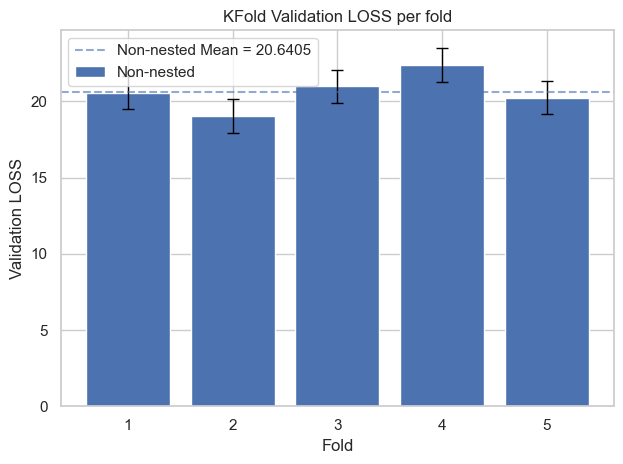

,TR,VL,Gap(TR-VL)
Fold,,,
1,10.688532,20.560375,9.871842
2,10.069117,19.035993,8.966876
3,12.377478,20.989243,8.611765
4,13.097683,22.389859,9.292176
5,11.986564,20.227265,8.240702
MEAN,11.643875,20.640547,8.996672
STD,1.110109,1.089358,0.561031


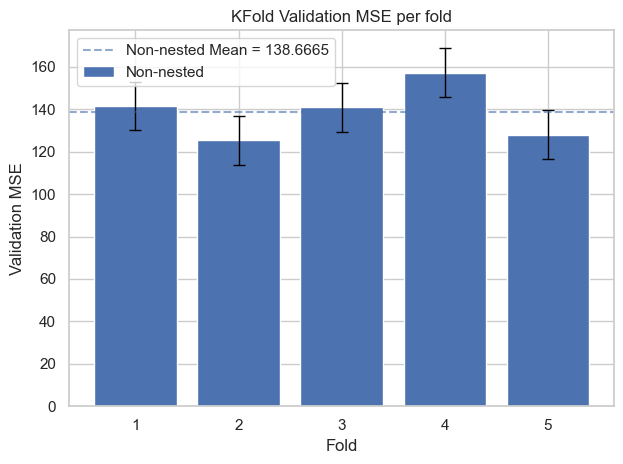

,TR,VL,Gap(TR-VL)
Fold,,,
1,55.082239,141.572892,86.490653
2,51.034815,125.367319,74.332505
3,63.354081,140.913572,77.559491
4,72.939769,157.360189,84.420420
5,66.036292,128.118583,62.082291
MEAN,61.689439,138.666511,76.977072
STD,7.815526,11.411198,8.661398


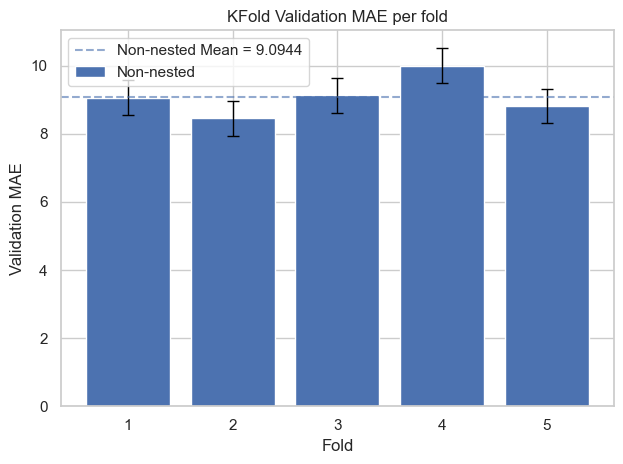

,TR,VL,Gap(TR-VL)
Fold,,,
1,4.646244,9.060405,4.414160
2,4.426170,8.460643,4.034473
3,5.490802,9.132688,3.641886
4,5.721766,10.001499,4.279734
5,5.311928,8.816602,3.504673
MEAN,5.119382,9.094367,3.974985
STD,0.498457,0.510739,0.352543


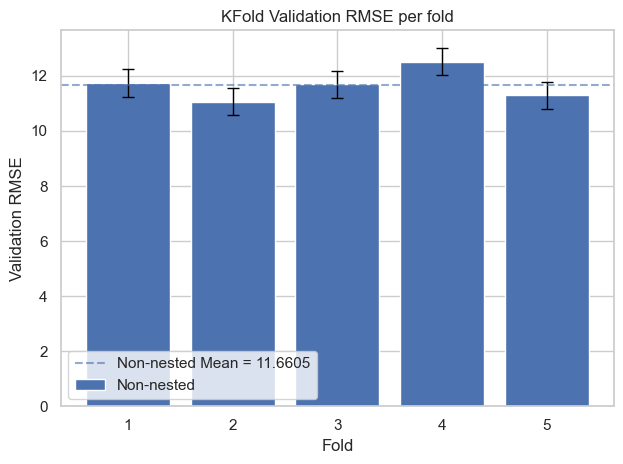

,TR,VL,Gap(TR-VL)
Fold,,,
1,7.205760,11.743915,4.538155
2,6.897015,11.066167,4.169152
3,7.803624,11.693829,3.890205
4,8.399580,12.509158,4.109578
5,7.897668,11.289551,3.391883
MEAN,7.640729,11.660524,4.019795
STD,0.531171,0.493786,0.376864


In [39]:
importlib.reload(cr)
for metric in the_metrics:
    cr.plot_kfold_metric([(fold_histories,"Non-nested")], metric)
    display(cr.kfold_summary(fold_histories, use=metric))


<h4>Bootstrap Variance</h4>

In [28]:

epochs_metrics_bootstrap_dict = {
    MEE: (cr.mee, min)
}

importlib.reload(cr)
importlib.reload(nnc)
bootstrap_samples_nr = 50
bootstrap_rstate = 42
samples = cr.generate_bootstrap_samples_from_dataset(X_tr, y_tr, n_samples=bootstrap_samples_nr, random_state=bootstrap_rstate)
runner = nnc.TorchRegressorRunner(model_template)
bootstrap_params = {}
bootstrap_params['train_params'] = copy.deepcopy(inner_train_params)
bootstrap_params['train_params']["silence_output"] = True
bootstrap_params['scaler'] = scaler
bootstrap_params['split_strategy'] = nnc.HoldOutStrategy
bootstrap_scores = cr.bootstrap_out_of_bag_scores(runner, X_tr, y_tr, samples, epochs_metrics_bootstrap_dict, bootstrap_params)

In [29]:
cr.aggregate_scores(bootstrap_scores)

,Metric,Mean,Std,%
0,MEE,25.7,1.07,4.18


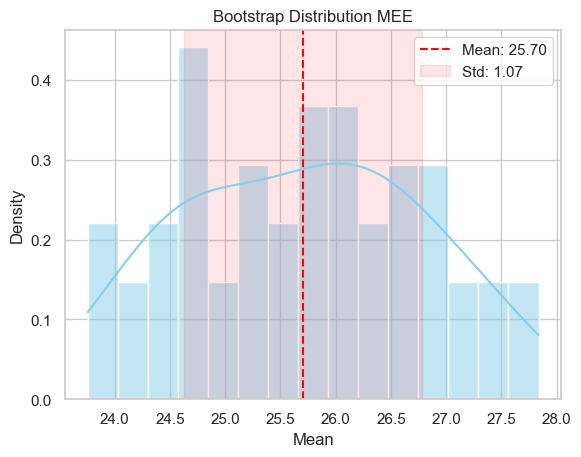

In [30]:
cr.plot_bootstrap_distribution([metric[MEE] for metric in bootstrap_scores], title=f"Bootstrap Distribution {MEE.upper()}")

<h4>Training</h4>
<p>Model is eventually trained with best hyper parameters from Optuna and assesed within KFold phase.</p>

In [40]:
importlib.reload(nnc)
model_final = copy.deepcopy(model_template)

train_kf_result = nnc.train(
    model_final, HoldOutStrategy(FeatureTargetSet(X_tr, y_tr), val_ratio=0.1, scaler=scaler), # 0.1 = 10%
    **inner_train_params
)

Early stopping at epoch 90 (best VL loss: 19.5755)
Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 1000
Train           | samples: 450
Validation      | samples: 50
Batch type      | mini-batch (16)
Loss function   | MEELoss(reduction='mean') - custom function
Optimizer       | class: <class 'torch.optim.adamw.AdamW'> , params: {'lr': 0.007119785296884371, 'weight_decay': 0.0003186696448140994, 'betas': (0.95, 0.999)}
LR Decay        | params: {'mode': 'min', 'factor': 0.5, 'patience': 10, 'threshold': 0.01}
Early Stopping  | metric: loss,  patience: 50 , minimum delta: 0.01
----------------------------------------------------------------------------------------------------


In [41]:
epochs_kf_vl_mee = train_kf_result.epochs_vl_loss
epochs_kf_tr_mee = train_kf_result.epochs_tr_loss
epochs_kf_tr_mse = train_kf_result.epochs_tr_mse
epochs_kf_vl_mse = train_kf_result.epochs_vl_mse
epochs_kf_grad = train_kf_result.epochs_grad_norm

<h5>Gradient Norm</h5>
<p>The gradient norm should gradually decrease throughout epochs, indicating that the optimization process moves toward a stable region of the loss landscape.</p>

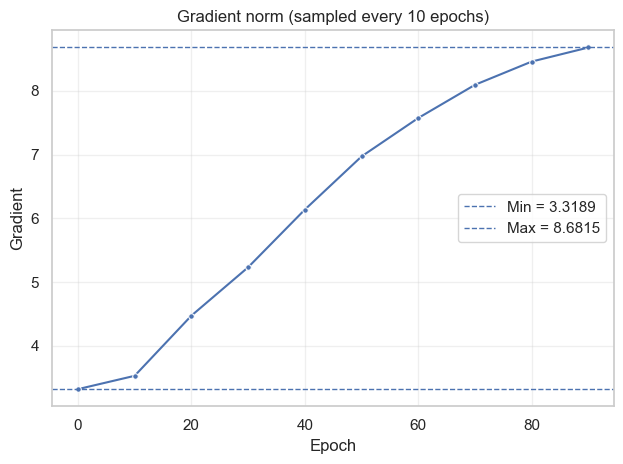

In [42]:
importlib.reload(nnc)
importlib.reload(cr)
nnc.plot_gradient_norm_line(epochs_kf_grad, step=10)

<h5>Epoch Loss</h5>

<Figure size 640x480 with 0 Axes>

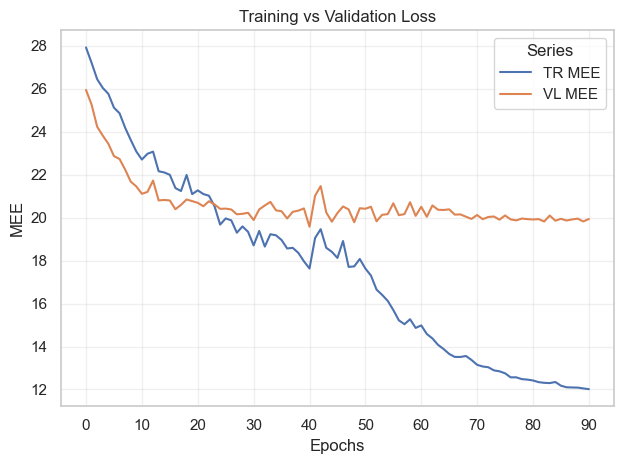

In [43]:
importlib.reload(nnc)
nnc.plot_epoch_mee(epochs_kf_tr_mee, epochs_kf_vl_mee)

<Figure size 640x480 with 0 Axes>

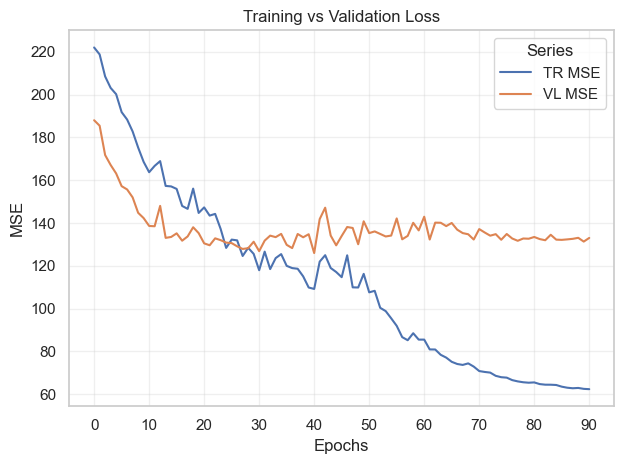

In [44]:
importlib.reload(nnc)
nnc.plot_epoch_mse(epochs_kf_tr_mse, epochs_kf_vl_mse)

In [ ]:
importlib.reload(cc)
mean, std = cr.mean_std_from_kfold(epochs_kf_vl_mee)
print(f"{mean:.4f} ± {std:.4f}")

<h3>Best Hyperparameters</h3>
<hr/>

In [47]:
print(f"hidden layers: {final_hidden_layers}")
print(f"activation function: {final_activation}")
for key, value in inner_train_params.items():
    print(f"{key}: {value}")



hidden layers: [256, 128]
activation function: tanh
epochs: 1000
batch_size: 16
scheduler_template: functools.partial(<class 'torch.optim.lr_scheduler.ReduceLROnPlateau'>, mode='min', factor=0.5, patience=10, threshold=0.01)
optimizer_template: functools.partial(<class 'torch.optim.adamw.AdamW'>, lr=0.007119785296884371, weight_decay=0.0003186696448140994, betas=(0.95, 0.999))
loss_function: MEELoss(reduction='mean') - custom function
early_stopping_strategy: EarlyStopping monitoring loss with patience=50, min_delta=0.01
additional_metrics: {'loss': (MEELoss(reduction='mean') - custom function, <built-in function min>), 'mse': (<function mse at 0x120403a00>, <built-in function min>), 'mae': (<function mae at 0x120403cc0>, <built-in function min>), 'rmse': (<function rmse at 0x120403ab0>, <built-in function min>)}
